/Users/apple/miniconda3/envs/llm_benchmark/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarchies https://seshat-db.com/api/core/variable

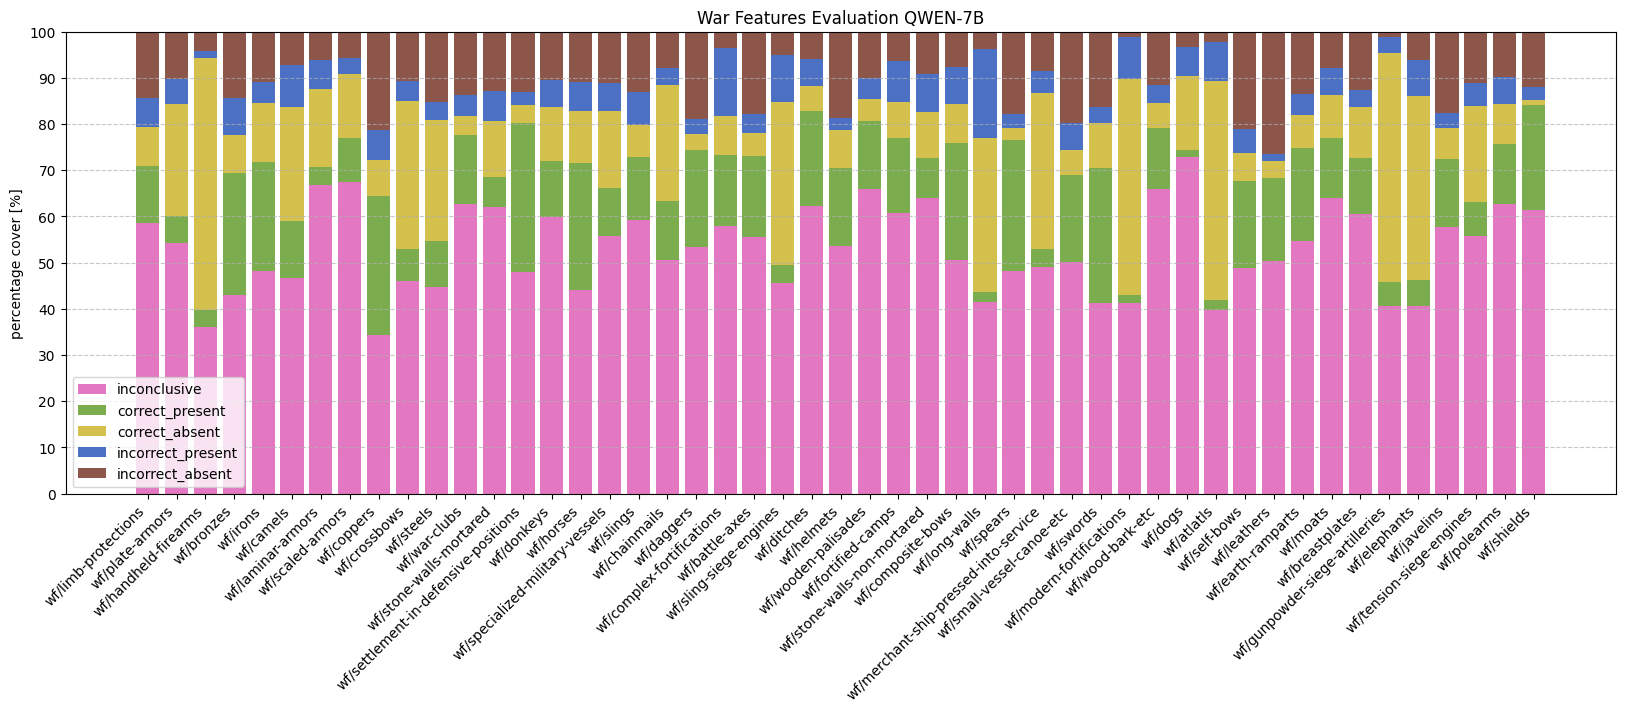

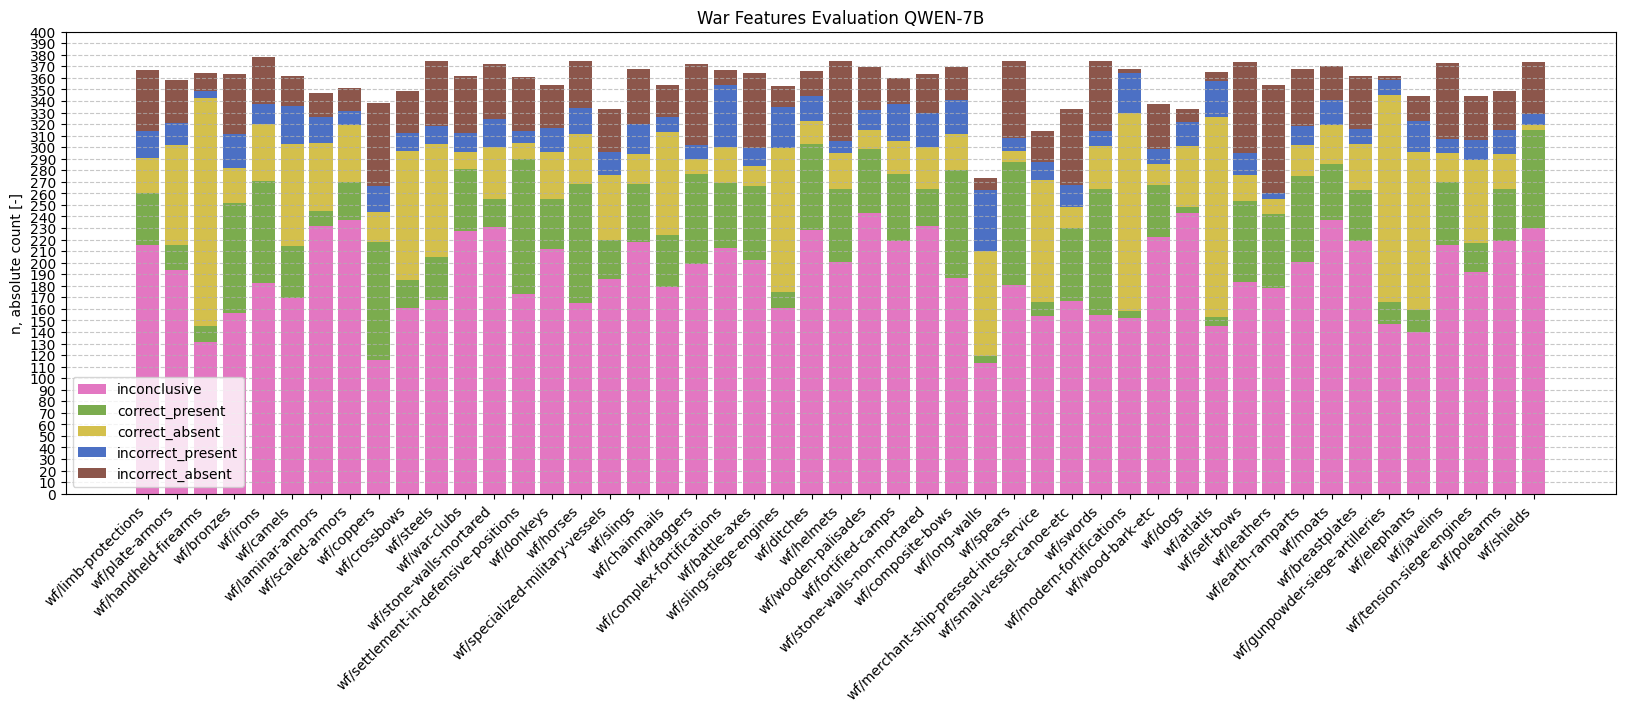

In [1]:
from typing import Dict, List, Any

from llm_benchmark.utils.dataset import Dataset, DatasetModule
from llm_benchmark.utils import benchmark
from llm_benchmark.data import eval
from llm_benchmark.display import plotting

from copy import deepcopy


dataset: Dataset = benchmark.seshat_setup(seshat_cache_dir="/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/seshat", force=False)
tally_all: List[Dict[str, Any]] = eval.tally_directory(dataset=dataset, dir="/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/evaluation/22_04_2026/run_3_Qwen_Qwen-7B-Chat/wf_answers/")

data = {}
for endpoint, data_single in tally_all.items():
    counts, strings = zip(*data_single.values())
    data.update({endpoint.replace("_answers", ""): zip(data_single.keys(), counts)})

plotting.plot_stacked_bar_chart(
    data=data,
    figsize=(20,6),
    title="War Features Evaluation QWEN-7B",
    absolute=False,
    y_limits=[0, 100],
    y_label="percentage cover [%]"
)
plotting.plot_stacked_bar_chart(
    data=data,
    figsize=(20,6),
    title="War Features Evaluation QWEN-7B",
    absolute=True,
    y_limits=[0, 400],
    y_label="n, absolute count [-]"
)

(215,)
$$$ 
I'm sorry, but I cannot provide an accurate answer to this question without more context and information. The term "limb protection" can refer to various types of protective gear worn by soldiers, including armor, shields, helmets, and other items designed to protect the limbs. The Durrani Empire, also known as the Afghan Empire, was a major power in South Asia during the 18th and early 19th centuries, and it is likely that its warriors would have used some form of limb protection in their military operations. However, without more specific information about the time period and type of warfare being referred to, it is not possible to say whether such protection was present or absent during the Durrani Empire.
$$$
$$$ 
The information regarding the use of limb protections like Karasulas armor during the Hephthalite Empire is not explicitly mentioned in the book "Mounted Archers of the Steppe 600 BC-AD 1300" by Antony Karasulas. Therefore, it cannot be inferred whether they w

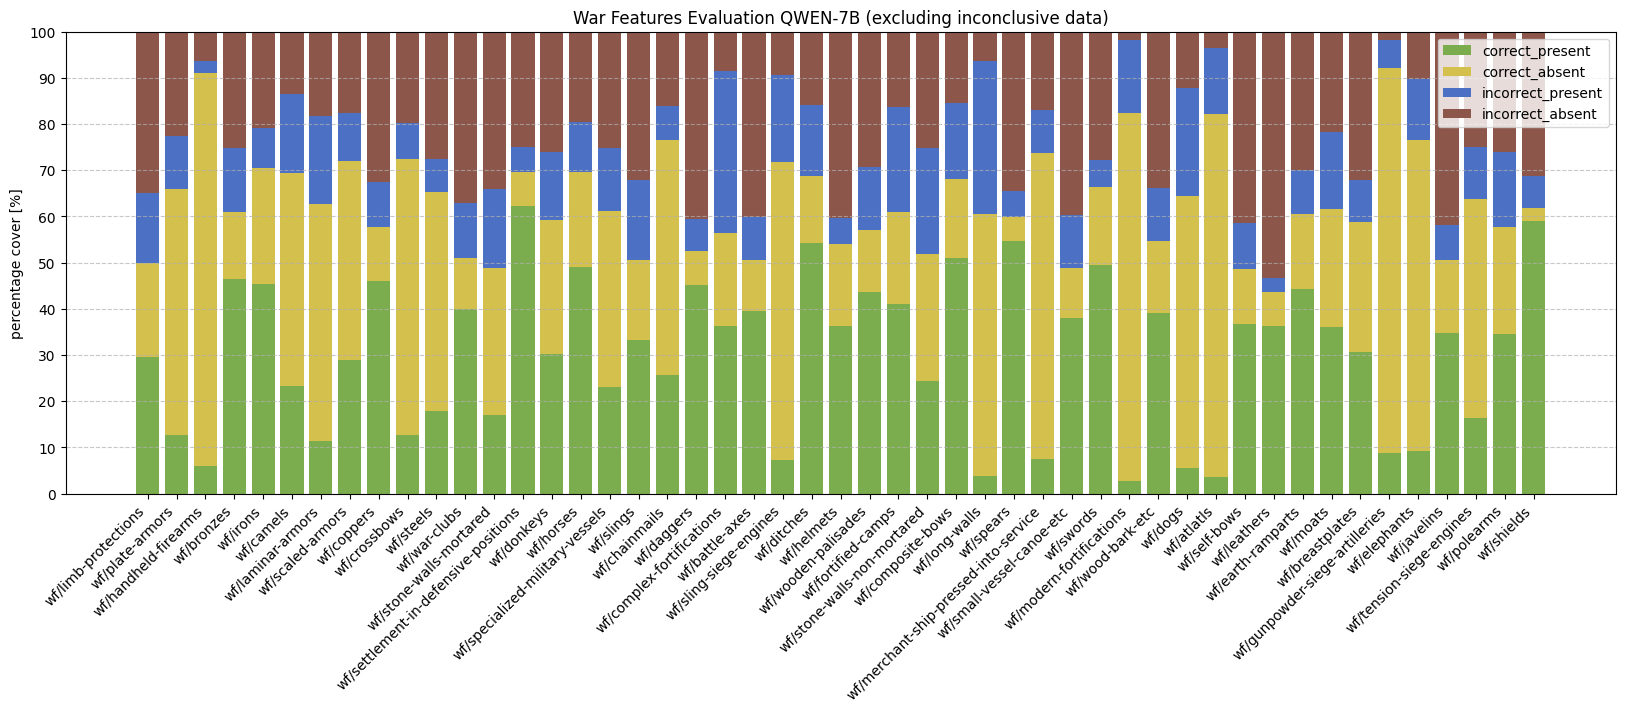

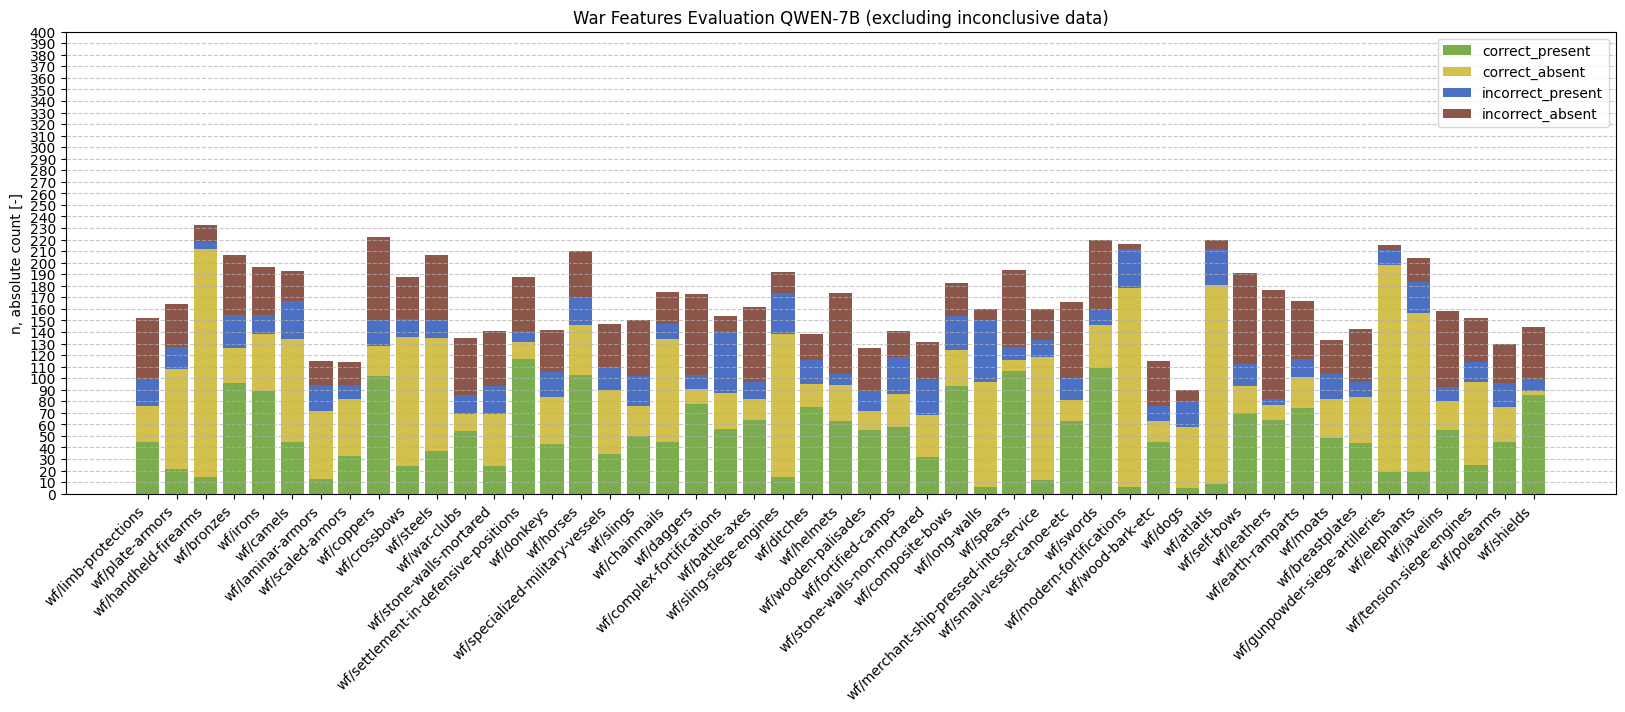

In [ ]:
data_stripped = {}
tally_copy = deepcopy(tally_all)
for endpoint, data_single in tally_copy.items():
    if "inconclusive" in data_single.keys(): 
        data_single.pop("inconclusive")
    counts, strings = zip(*data_single.values())
    data_stripped.update({endpoint.replace("_answers", ""): zip(data_single.keys(), counts)})


counts, strings = zip(tally_all["wf/limb-protections_answers"]["inconclusive"])
for st in strings[0]:
    print(f"$$$ \n{st}\n$$$")

plotting.plot_stacked_bar_chart(
    data=data_stripped,
    colours=['#7bac4e', '#d4c04c', '#4c70c4', '#8c564b'],
    figsize=(20,6),
    title="War Features Evaluation QWEN-7B (excluding inconclusive data)",
    absolute=False,
    y_limits=[0, 100],
    y_label="percentage cover [%]"
)
plotting.plot_stacked_bar_chart(
    data=data_stripped,
    colours=['#7bac4e', '#d4c04c', '#4c70c4', '#8c564b'],
    figsize=(20,6),
    title="War Features Evaluation QWEN-7B (excluding inconclusive data)",
    absolute=True,
    y_limits=[0, 400],
    y_label="n, absolute count [-]"
)

In [36]:
import polars as pl

dataset: Dataset = benchmark.seshat_setup(seshat_cache_dir="/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/seshat", force=False)
qwen_7b_tally_all: List[Dict[str, Any]] = eval.tally_directory(dataset=dataset, dir="/Users/apple/Documents/github/neurips_llms/llm-bechmark/db/evaluation/22_04_2026/run_3_Qwen_Qwen-7B-Chat/wf_answers/")

data = {}

across: List[Dict[str, int]] = [{}, {}, {}, {}, {}]

for endpoint, data_single in tally_all.items():
    counts, strings = zip(*data_single.values())
    data.update({endpoint.replace("_answers", ""): zip(data_single.keys(), counts)})
    for idx, count in enumerate(counts):
        across[idx].update({endpoint.replace("_answers", ""): count})

dataframe: pl.DataFrame = pl.DataFrame(across)
labelled: pl.DataFrame = dataframe.with_columns(
    pl.Series("row_label", ["inconclusive", "correct_present", "correct_absent", "incorrect_present", "incorrect_absent"])
).select(["row_label", pl.all().exclude("row_label")])
with pl.Config(tbl_cols=-1) and pl.Config(tbl_width_chars=1000):
    print("\n\nTABLE OF WARFARE FEATURE EVALUATION QWEN -> ABSOLUTE VALUES")
    print(labelled.head())


with pl.Config(tbl_cols=-1) and pl.Config(tbl_width_chars=1000):
    numeric_cols = [c for c in labelled.columns if c != "row_label"]
    percent_df = labelled.with_columns([
        (pl.col(col) / pl.col(col).sum() * 100).alias(col).round(2)
        for col in numeric_cols
    ])

    print("\n\nTABLE OF WARFARE FEATURE EVALUATION QWEN -> PERCENTAGE [%] VALUES")
    print(percent_df.head())


with pl.Config(tbl_cols=-1) and pl.Config(tbl_width_chars=1000):
    numeric_cols = [c for c in labelled.columns if c != "row_label"]
    percent_df = labelled.filter(pl.col("row_label") != "inconclusive").with_columns([
        (pl.col(col) / pl.col(col).sum() * 100).alias(col).round(2)
        for col in numeric_cols
    ])

    print("\n\nTABLE OF WARFARE FEATURE EVALUATION QWEN -> PERCENTAGE [%] VALUES, EXCLUDING INCONCLUSIVE")
    print(percent_df.head())



Attempting dataset refresh. False
core/macro-regions https://seshat-db.com/api/core/macro-regions/
Ignoring polity core/macro-regions as per configuration.
core/regions https://seshat-db.com/api/core/regions/
Ignoring polity core/regions as per configuration.
core/ngas https://seshat-db.com/api/core/ngas/
Ignoring polity core/ngas as per configuration.
core/polities https://seshat-db.com/api/core/polities/
Ignoring polity core/polities as per configuration.
core/capitals https://seshat-db.com/api/core/capitals/
Ignoring polity core/capitals as per configuration.
core/nga-polity-relations https://seshat-db.com/api/core/nga-polity-relations/
Ignoring polity core/nga-polity-relations as per configuration.
core/sections https://seshat-db.com/api/core/sections/
Ignoring polity core/sections as per configuration.
core/subsections https://seshat-db.com/api/core/subsections/
Ignoring polity core/subsections as per configuration.
core/variable-hierarchies https://seshat-db.com/api/core/variable